<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_THDeepLearn_tuan3_b3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# 1. Load dl Fashion-MNIST
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Tang chieu cho anh  (28, 28) -> (28, 28, 1) va chuan hoa ve [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


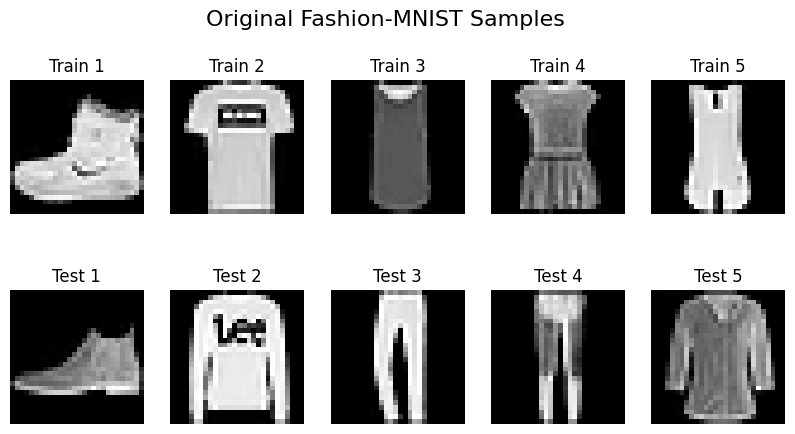

In [4]:
n_samples = 5
plt.figure(figsize=(10, 5))
for i in range(n_samples):
    # Display original training images
    ax = plt.subplot(2, n_samples, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Train {i+1}")
    plt.axis('off')

    # Display original test images
    ax = plt.subplot(2, n_samples, i + 1 + n_samples)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Test {i+1}")
    plt.axis('off')
plt.suptitle('Original Fashion-MNIST Samples', fontsize=16)
plt.show()

In [5]:

# 2. Autoencoder cho Fashion-MNIST
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(x)
output_img = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_fashion = models.Model(input_img, output_img)
autoencoder_fashion.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder_fashion.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
 #3. Huấn luyện mô hình
autoencoder_fashion.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
history = autoencoder_fashion.fit(
    x_train, x_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 155ms/step - accuracy: 0.5088 - loss: 0.2686 - val_accuracy: 0.5067 - val_loss: 0.2702
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 144ms/step - accuracy: 0.5089 - loss: 0.2676 - val_accuracy: 0.5068 - val_loss: 0.2692
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 148ms/step - accuracy: 0.5091 - loss: 0.2665 - val_accuracy: 0.5069 - val_loss: 0.2681
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 147ms/step - accuracy: 0.5091 - loss: 0.2655 - val_accuracy: 0.5069 - val_loss: 0.2672
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 148ms/step - accuracy: 0.5092 - loss: 0.2647 - val_accuracy: 0.5070 - val_loss: 0.2665


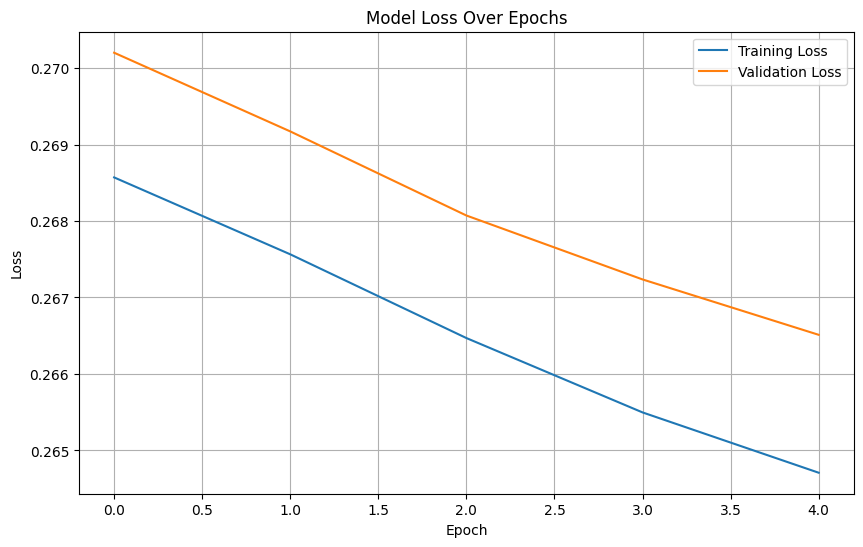

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


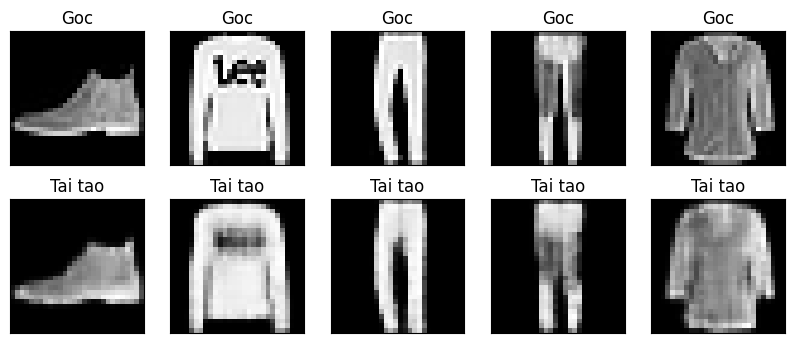

In [14]:
# 4. Truc quan hoa kq
decoded_imgs = autoencoder_fashion.predict(x_test)

n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # goc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Goc")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # sau Autoencoder
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Tai tao")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()